# 09 — Side effects and the direction problem

nb11's literature check turned up something the ranking metrics never showed. Among the GCN's top-scoring `y = 0` pairs, several of the strongest by literature volume are relationships that run **backwards**:

| Prediction | Papers | What the literature is actually about |
|---|---|---|
| Epinephrine × hypertension | 1,773 | epinephrine is a vasopressor — it *raises* blood pressure |
| Indomethacin × hypertension | 1,047 | NSAIDs *elevate* blood pressure |
| Prednisolone × hypertension | 897 | corticosteroids *cause* hypertension |
| Methylprednisolone × hypertension | 708 | same |

The model was trained only on `treats` edges, yet it ranks drug–disease pairs highly whether the drug treats the disease or causes it. What it appears to have learned is "these two are clinically entangled", with no sense of direction.

This is measurable. Hetionet carries 5,734 **Side Effect** nodes and 138,944 `Compound–causes–Side Effect` edges, and 53 disease names appear verbatim as side-effect names — so for those diseases we can ask directly whether a predicted compound is *known to cause* the condition. On the CGD subgraph the GCN's top-300 sits at **6.0 %** by that measure, against 4.0 % for the matched control.

## The hypothesis

nb08 found that R-GCN did not beat GCN, and concluded edge-type awareness was not where the next gain lived. That conclusion was drawn on a graph where it could not possibly have helped: **the C∪G∪D subgraph contains no edge type that distinguishes therapy from harm.** Every relation in it (`binds`, `interacts`, `associates`, `upregulates`, …) is direction-neutral with respect to treatment.

Adding Side Effect nodes changes that. `causes` is exactly the relation that carries the distinction, and it is the one relation R-GCN can weight separately and GCN cannot.

| Model | Sees `causes` edges? | Can weight them differently? |
|---|---|---|
| GCN + Side Effect | yes | **no** — one shared weight matrix |
| R-GCN + Side Effect | yes | **yes** — per-relation matrices |

**Primary metric is not AUROC.** The question is whether the `drug_causes_disease` rate among top predictions falls. AUROC and AUPRC are reported as guardrails: a model that fixes the direction problem by getting worse at everything has not fixed anything.

## 1 · Setup

In [1]:
from __future__ import annotations
import json, pathlib, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.metrics import roc_auc_score, average_precision_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, RGCNConv

from utils import load_hetnet, setup_plot_style
setup_plot_style()

ART = pathlib.Path("artifacts")
EXT = ART / "external"

device = (torch.device("mps") if torch.backends.mps.is_available()
          else torch.device("cuda") if torch.cuda.is_available()
          else torch.device("cpu"))
print(f"Device: {device}")

meta  = json.loads((ART / "splits" / "split_meta.json").read_text())
pairs = pd.read_parquet(ART / "splits" / "pairs.parquet")
split = np.load(ART / "splits" / "lr_split.npz")
idx_train, idx_test = split["idx_train"], split["idx_test"]
SEED = int(meta["split_seed"])
y = pairs["y"].to_numpy()
torch.manual_seed(SEED); np.random.seed(SEED)
print(f"Pairs {len(pairs):,} | positives {int(y.sum())} | test positives {int(y[idx_test].sum())}")


Device: mps
Pairs 206,312 | positives 755 | test positives 151


## 2 · Two graphs, differing only by Side Effect

`CGD` reproduces nb08 exactly. `CGD+SE` adds the Side Effect nodes and their `causes` edges and nothing else, so any difference between the two is attributable to that relation.

In [2]:
HUB_K = 20

t0 = time.time()
hetnet = load_hetnet()
print(f"Loaded hetnet in {time.time() - t0:.1f}s")

pos_mask  = y == 1
test_mask = np.zeros(len(pairs), dtype=bool); test_mask[idx_test] = True
test_positives  = pairs.loc[pos_mask &  test_mask, ["compound", "disease"]]
train_positives = pairs.loc[pos_mask & ~test_mask, ["compound", "disease"]]


def build_graph(keep_kinds):
    G = nx.Graph()
    for n in hetnet["nodes"]:
        if n["kind"] in keep_kinds:
            G.add_node((n["kind"], n["identifier"]), kind=n["kind"], name=n["name"])
    kept = set(G.nodes())
    for e in hetnet["edges"]:
        u, v = tuple(e["source_id"]), tuple(e["target_id"])
        if u in kept and v in kept:
            G.add_edge(u, v, kind=e["kind"])
    dropped = 0
    for c, d in test_positives.itertuples(index=False):
        if G.has_edge(("Compound", c), ("Disease", d)):
            G.remove_edge(("Compound", c), ("Disease", d)); dropped += 1
    gene_deg = sorted(((n, deg) for n, deg in G.degree() if n[0] == "Gene"), key=lambda x: -x[1])
    G.remove_nodes_from([n for n, _ in gene_deg[:HUB_K]])
    G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
    return G, dropped


graphs = {}
for tag, kinds in [("CGD",    {"Compound", "Gene", "Disease"}),
                   ("CGD+SE", {"Compound", "Gene", "Disease", "Side Effect"})]:
    G, dropped = build_graph(kinds)
    rels = pd.Series([d["kind"] for _, _, d in G.edges(data=True)]).value_counts()
    graphs[tag] = {"G": G, "dropped": dropped, "rels": rels}
    print(f"\n[{tag}] {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges, "
          f"{dropped} test CtD dropped, {len(rels)} relations")
    print(rels.to_string())


Loaded hetnet in 11.6s



[CGD] 19,683 nodes, 525,174 edges, 151 test CtD dropped, 10 relations
regulates        245657
interacts        132247
covaries          61504
downregulates     27669
upregulates       26134
associates        12440
binds             11505
resembles          7024
treats              604
palliates           390



[CGD+SE] 25,403 nodes, 664,123 edges, 151 test CtD dropped, 11 relations
regulates        245657
causes           138944
interacts        132247
covaries          61504
downregulates     27669
upregulates       26134
associates        12440
binds             11505
resembles          7029
treats              604
palliates           390


## 3 · Tensors and models

Same architecture and shared training loop as nb08 — `LinkPredictor` with `relation_aware` toggling GCN against R-GCN — so the only new variable in this notebook is the graph.

In [3]:
def to_tensors(G):
    node_list = list(G.nodes())
    node_idx = {n: i for i, n in enumerate(node_list)}
    relation_names = sorted({d["kind"] for _, _, d in G.edges(data=True)})
    rel_idx = {k: i for i, k in enumerate(relation_names)}

    src, dst, rel = [], [], []
    for u, v, edata in G.edges(data=True):
        r = rel_idx[edata["kind"]]
        src.extend([node_idx[u], node_idx[v]]); dst.extend([node_idx[v], node_idx[u]])
        rel.extend([r, r])

    cmap = {n[1]: node_idx[n] for n in node_list if n[0] == "Compound"}
    dmap = {n[1]: node_idx[n] for n in node_list if n[0] == "Disease"}

    def edge_tensor(df):
        us, vs, mask = [], [], []
        for c, d in df[["compound", "disease"]].itertuples(index=False):
            u, v = cmap.get(c, -1), dmap.get(d, -1)
            ok = u >= 0 and v >= 0
            us.append(u if ok else 0); vs.append(v if ok else 0); mask.append(ok)
        return (torch.tensor([us, vs], dtype=torch.long),
                torch.tensor(mask, dtype=torch.bool))

    train_pos, _   = edge_tensor(train_positives)
    eval_e, have   = edge_tensor(pairs)
    return {
        "node_list": node_list, "num_nodes": len(node_list),
        "relation_names": relation_names, "num_relations": len(relation_names),
        "edge_index": torch.tensor([src, dst], dtype=torch.long).to(device),
        "edge_type":  torch.tensor(rel, dtype=torch.long).to(device),
        "train_pos":  train_pos.to(device), "eval_edges": eval_e.to(device), "have": have,
        "compound_idx": np.array([i for i, n in enumerate(node_list) if n[0] == "Compound"]),
        "disease_idx":  np.array([i for i, n in enumerate(node_list) if n[0] == "Disease"]),
        "train_pos_pairs": set(zip(train_pos[0].tolist(), train_pos[1].tolist())),
    }


for tag in graphs:
    graphs[tag]["T"] = to_tensors(graphs[tag]["G"])
    T = graphs[tag]["T"]
    print(f"[{tag}] num_nodes {T['num_nodes']:,} | relations {T['num_relations']} | "
          f"eval coverage {T['have'].float().mean():.1%}")


[CGD] num_nodes 19,683 | relations 10 | eval coverage 100.0%


[CGD+SE] num_nodes 25,403 | relations 11 | eval coverage 100.0%


In [4]:
HIDDEN_DIM, NUM_BASES, DROPOUT, LR, EPOCHS = 64, 8, 0.2, 0.01, 200


class LinkPredictor(nn.Module):
    def __init__(self, num_nodes, hidden_dim, dropout, relation_aware=False,
                 num_relations=None, num_bases=None):
        super().__init__()
        self.relation_aware = relation_aware
        self.node_emb = nn.Embedding(num_nodes, hidden_dim)
        nn.init.xavier_uniform_(self.node_emb.weight)
        if relation_aware:
            self.conv1 = RGCNConv(hidden_dim, hidden_dim, num_relations, num_bases=num_bases)
            self.conv2 = RGCNConv(hidden_dim, hidden_dim, num_relations, num_bases=num_bases)
        else:
            self.conv1 = GCNConv(hidden_dim, hidden_dim)
            self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.dropout = dropout

    def encode(self, edge_index, edge_type=None):
        x = self.node_emb.weight
        args = (edge_index, edge_type) if self.relation_aware else (edge_index,)
        x = F.relu(self.conv1(x, *args))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.conv2(x, *args)

    @staticmethod
    def decode(z, edges):
        return (z[edges[0]] * z[edges[1]]).sum(dim=-1)


def train_one(graph_tag, relation_aware, epochs=EPOCHS, log_every=50):
    T = graphs[graph_tag]["T"]
    torch.manual_seed(SEED)
    rng = np.random.default_rng(SEED)
    model = LinkPredictor(T["num_nodes"], HIDDEN_DIM, DROPOUT,
                          relation_aware=relation_aware,
                          num_relations=T["num_relations"], num_bases=NUM_BASES).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    et = T["edge_type"] if relation_aware else None
    name = f"{'rgcn' if relation_aware else 'gcn'} @ {graph_tag}"

    t0 = time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        n_pos = T["train_pos"].size(1)
        us, vs, tries = [], [], 0
        while len(us) < n_pos and tries < n_pos * 10:
            c = int(T["compound_idx"][rng.integers(0, len(T["compound_idx"]))])
            d = int(T["disease_idx"][rng.integers(0, len(T["disease_idx"]))])
            if (c, d) not in T["train_pos_pairs"]:
                us.append(c); vs.append(d)
            tries += 1
        neg = torch.tensor([us, vs], dtype=torch.long).to(device)

        z = model.encode(T["edge_index"], et)
        pos_s, neg_s = model.decode(z, T["train_pos"]), model.decode(z, neg)
        loss = F.binary_cross_entropy_with_logits(
            torch.cat([pos_s, neg_s]),
            torch.cat([torch.ones_like(pos_s), torch.zeros_like(neg_s)]))
        opt.zero_grad(); loss.backward(); opt.step()
        if epoch % log_every == 0:
            print(f"  [{name}] epoch {epoch:3d}  loss {loss.item():.4f}")

    model.eval()
    with torch.no_grad():
        s = model.decode(model.encode(T["edge_index"], et), T["eval_edges"]).cpu().numpy()
    s[~T["have"].numpy()] = -1e9
    return {"name": name, "graph": graph_tag, "relation_aware": relation_aware,
            "scores": s, "seconds": time.time() - t0,
            "n_params": sum(p.numel() for p in model.parameters())}


runs = {}
for graph_tag in ("CGD", "CGD+SE"):
    for ra in (False, True):
        r = train_one(graph_tag, ra)
        runs[r["name"]] = r
        print(f"  -> {r['name']}: {r['seconds']:.0f}s, {r['n_params']:,} params")


  [gcn @ CGD] epoch  50  loss 0.3078


  [gcn @ CGD] epoch 100  loss 0.1722


  [gcn @ CGD] epoch 150  loss 0.1416


  [gcn @ CGD] epoch 200  loss 0.0609


  -> gcn @ CGD: 307s, 1,268,032 params


...

  [rgcn @ CGD+SE] epoch  50  loss 0.0567


  [rgcn @ CGD+SE] epoch 100  loss 0.0293


  [rgcn @ CGD+SE] epoch 150  loss 0.0144


  [rgcn @ CGD+SE] epoch 200  loss 0.0154


  -> rgcn @ CGD+SE: 637s, 1,699,824 params


## 4 · The direction metric

53 Hetionet disease names appear verbatim as Side Effect names, so for pairs involving those diseases we can check whether the compound has a recorded `causes` edge to the matching side effect. Among the top-K predictions, a lower rate means the model is doing a better job of separating therapy from harm.

The measure is conservative in two ways: it only covers 53 of 137 diseases, and it requires an exact name match. It undercounts, but it undercounts identically for every model.

In [5]:
se_names = {n["name"].lower(): n["identifier"] for n in hetnet["nodes"] if n["kind"] == "Side Effect"}
dz_names = {n["identifier"]: n["name"].lower() for n in hetnet["nodes"] if n["kind"] == "Disease"}
se_id2name = {v: k for k, v in se_names.items()}

c2se = {}
for e in hetnet["edges"]:
    u, v = tuple(e["source_id"]), tuple(e["target_id"])
    if {u[0], v[0]} != {"Compound", "Side Effect"}:
        continue
    c, se = (u, v) if u[0] == "Compound" else (v, u)
    c2se.setdefault(c[1], set()).add(se_id2name.get(se[1], ""))

covered = set(se_names) & set(dz_names.values())
print(f"Diseases checkable by exact name match: {len(covered)} of {len(dz_names)}")

pair_c = pairs["compound"].to_numpy()
pair_d = pairs["disease"].to_numpy()
causes_flag = np.array([dz_names.get(d, "") in c2se.get(c, set())
                        for c, d in zip(pair_c, pair_d)])
checkable = np.array([dz_names.get(d, "") in covered for d in pair_d])
print(f"Pairs where the compound is a known cause of the disease: {causes_flag.sum():,} "
      f"of {checkable.sum():,} checkable")


Diseases checkable by exact name match: 53 of 137
Pairs where the compound is a known cause of the disease: 2,396 of 80,401 checkable


In [6]:
y_test = y[idx_test]
K_LIST = [50, 100, 300]

rows = []
for name, r in runs.items():
    st = r["scores"][idx_test]
    order = np.argsort(-st)
    row = {"model": name,
           "AUROC": round(float(roc_auc_score(y_test, st)), 4),
           "AUPRC": round(float(average_precision_score(y_test, st)), 4)}
    # direction metric on top-K novel predictions (y=0 only)
    test_y   = y[idx_test][order]
    test_cf  = causes_flag[idx_test][order]
    test_chk = checkable[idx_test][order]
    novel = test_y == 0
    for K in K_LIST:
        top_novel = np.where(novel)[0][:K]
        row[f"causes@{K}"] = round(float(test_cf[top_novel].mean()), 4)
    # restricted to pairs the metric can actually see
    top_chk = np.where(novel & test_chk)[0][:100]
    row["causes@100_checkable_only"] = round(float(test_cf[top_chk].mean()), 4)
    row["seconds"] = round(r["seconds"], 0)
    rows.append(row)

results = pd.DataFrame(rows)
results


,model,AUROC,AUPRC,causes@50,causes@100,causes@300,causes@100_checkable_only,seconds
0,gcn @ CGD,0.9218,0.1781,0.10,0.06,0.0600,0.09,307.0
1,rgcn @ CGD,0.9179,0.1545,0.04,0.06,0.0400,0.09,395.0
2,gcn @ CGD+SE,0.8727,0.0941,0.22,0.15,0.1000,0.17,440.0
3,rgcn @ CGD+SE,0.8639,0.1584,0.04,0.05,0.0233,0.06,637.0


### 4a · Did edge-type awareness help, and did the graph?

Two comparisons matter, and they answer different questions:

- **R-GCN vs GCN on `CGD+SE`** — with `causes` edges present, does per-relation weighting reduce the confusion? This is the hypothesis under test.
- **`CGD+SE` vs `CGD` for each model** — does merely seeing side-effect structure help, regardless of whether the model can weight it separately?

In [7]:
piv = results.set_index("model")
def get(model, col):
    return float(piv.loc[model, col])

print("Direction metric — causes@100 among novel predictions (lower is better)")
print(f"{'':22s} {'CGD':>10s} {'CGD+SE':>10s} {'delta':>10s}")
for kind in ("gcn", "rgcn"):
    a = get(f"{kind} @ CGD", "causes@100")
    b = get(f"{kind} @ CGD+SE", "causes@100")
    print(f"{kind:22s} {a:>10.3f} {b:>10.3f} {b - a:>+10.3f}")
print()
print("Edge-type awareness within each graph (rgcn - gcn):")
for g in ("CGD", "CGD+SE"):
    d_causes = get(f"rgcn @ {g}", "causes@100") - get(f"gcn @ {g}", "causes@100")
    d_auprc  = get(f"rgcn @ {g}", "AUPRC")     - get(f"gcn @ {g}", "AUPRC")
    print(f"  {g:8s}  causes@100 {d_causes:+.3f}   AUPRC {d_auprc:+.4f}")
print()
print("Guardrail — ranking quality must not collapse:")
print(results[["model", "AUROC", "AUPRC"]].to_string(index=False))


Direction metric — causes@100 among novel predictions (lower is better)
                              CGD     CGD+SE      delta
gcn                         0.060      0.150     +0.090
rgcn                        0.060      0.050     -0.010

Edge-type awareness within each graph (rgcn - gcn):
  CGD       causes@100 +0.000   AUPRC -0.0236
  CGD+SE    causes@100 -0.100   AUPRC +0.0643

Guardrail — ranking quality must not collapse:
        model  AUROC  AUPRC
    gcn @ CGD 0.9218 0.1781
   rgcn @ CGD 0.9179 0.1545
 gcn @ CGD+SE 0.8727 0.0941
rgcn @ CGD+SE 0.8639 0.1584


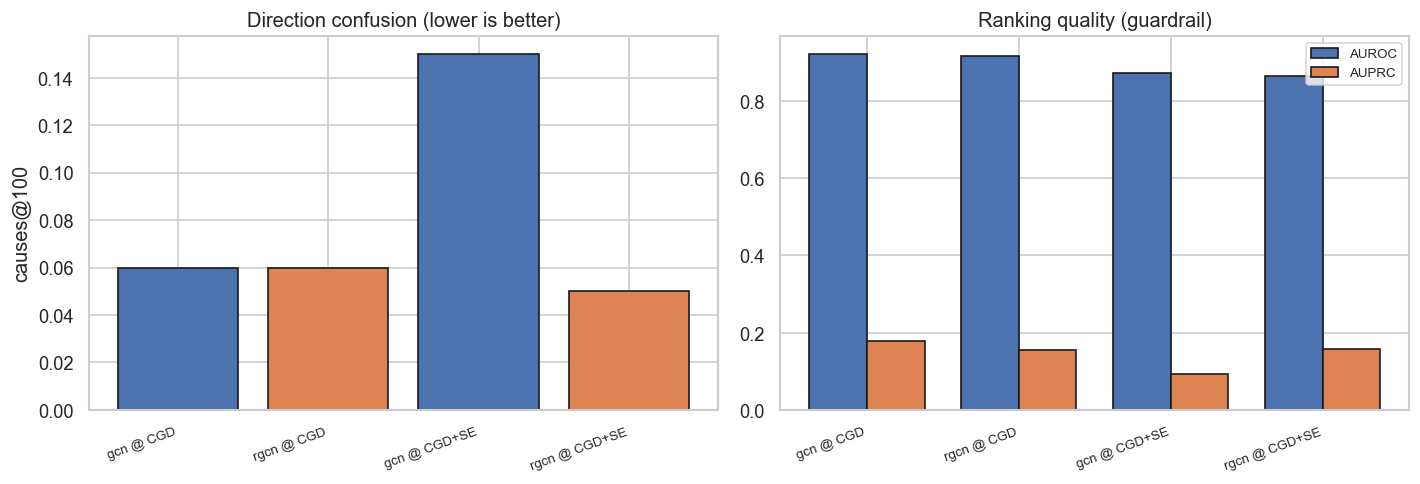

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
labels = list(results["model"])
x = np.arange(len(labels))

axes[0].bar(x, results["causes@100"], color=["C0", "C1", "C0", "C1"], edgecolor="k")
axes[0].set(xticks=x, ylabel="causes@100", title="Direction confusion (lower is better)")
axes[0].set_xticklabels(labels, rotation=20, ha="right", fontsize=8)

w = 0.38
axes[1].bar(x - w/2, results["AUROC"], w, label="AUROC", edgecolor="k")
axes[1].bar(x + w/2, results["AUPRC"], w, label="AUPRC", edgecolor="k")
axes[1].set(xticks=x, title="Ranking quality (guardrail)")
axes[1].set_xticklabels(labels, rotation=20, ha="right", fontsize=8)
axes[1].legend(fontsize=8)
plt.tight_layout()


### 4b · Which pairs drive the metric

In [9]:
cname = {n["identifier"]: n["name"] for n in hetnet["nodes"] if n["kind"] == "Compound"}
dname = {n["identifier"]: n["name"] for n in hetnet["nodes"] if n["kind"] == "Disease"}

best_model = results.sort_values("causes@100").iloc[0]["model"]
worst_model = results.sort_values("causes@100").iloc[-1]["model"]
print(f"Lowest confusion: {best_model} | highest: {worst_model}")
print()
for tag in (worst_model, best_model):
    st = runs[tag]["scores"][idx_test]
    order = np.argsort(-st)
    novel = np.where(y[idx_test][order] == 0)[0][:100]
    idx = order[novel]
    flagged = [(cname[pairs['compound'].iloc[idx_test[i]]],
                dname[pairs['disease'].iloc[idx_test[i]]])
               for i in idx if causes_flag[idx_test[i]]]
    print(f"[{tag}] {len(flagged)} of top-100 novel are known drug-causes-disease:")
    for c, d in flagged[:8]:
        print(f"    {c:24s} x {d}")
    print()


Lowest confusion: rgcn @ CGD+SE | highest: gcn @ CGD+SE

[gcn @ CGD+SE] 15 of top-100 novel are known drug-causes-disease:
    Topiramate               x hypertension
    Salbutamol               x hypertension
    Bupropion                x hypertension
    Gabapentin               x hypertension
    Pravastatin              x hypertension
    Dorzolamide              x hypertension
    Rivastigmine             x coronary artery disease
    Loratadine               x hypertension

[rgcn @ CGD+SE] 5 of top-100 novel are known drug-causes-disease:
    Naproxen                 x asthma
    Acamprosate              x psoriasis
    Mycophenolic acid        x asthma
    Gabapentin               x hypertension
    Topiramate               x hypertension



## 5 · Persist

In [10]:
for name, r in runs.items():
    key = name.replace(" @ ", "_").replace("+", "")
    out = pairs[["compound", "disease", "y"]].copy()
    out["score"] = r["scores"]
    out["in_test"] = test_mask
    out.to_parquet(ART / "predictions" / f"se_{key}.parquet")

se_meta = {
    "produced_by": "09_sideeffect_rgcn.ipynb",
    "question": "does edge-type awareness reduce treats/causes confusion when the graph carries a causes relation",
    "graphs": {t: {"n_nodes": int(graphs[t]["G"].number_of_nodes()),
                   "n_edges": int(graphs[t]["G"].number_of_edges()),
                   "relations": int(graphs[t]["T"]["num_relations"]),
                   "test_ctd_dropped": int(graphs[t]["dropped"])} for t in graphs},
    "config": {"hidden_dim": HIDDEN_DIM, "num_bases": NUM_BASES, "dropout": DROPOUT,
               "lr": LR, "epochs": EPOCHS, "hub_K": HUB_K, "seed": SEED, "device": str(device)},
    "direction_metric": {
        "definition": "compound has a Compound-causes-SideEffect edge whose side-effect name matches the disease name exactly",
        "diseases_covered": len(covered), "diseases_total": len(dz_names),
        "baseline_gcn_cgd_top300_from_nb11": 0.06,
    },
    "results": results.to_dict(orient="records"),
}
(ART / "predictions" / "sideeffect_rgcn_meta.json").write_text(json.dumps(se_meta, indent=2, default=str))
print("Wrote artifacts/predictions/sideeffect_rgcn_meta.json + four score files")


Wrote artifacts/predictions/sideeffect_rgcn_meta.json + four score files


## 6 · How to read this

**If R-GCN on `CGD+SE` shows a clear drop in `causes@100` while GCN does not**, then nb08's conclusion needs its scope narrowed: edge-type awareness is not useless, it was tested on a graph where no relation carried the distinction it could exploit. That would make the direction problem an architecture question after all.

**If both models move together**, the gain is from seeing side-effect structure at all, not from weighting it — a cheaper finding, and one that favours simply adding the nodes over adopting R-GCN.

**If neither moves**, the confusion is not something message passing can fix from graph structure alone. The next lever would then be the loss: currently every non-`treats` pair is an equally good negative, so a compound known to *cause* a disease is sampled as a negative no more often than an unrelated one. Weighting those pairs up during negative sampling would attack the problem directly, and connects to the screened negative set from nb11.

Either way the guardrail applies: a drop in `causes@100` bought with a collapse in AUPRC is not a fix.